# 1. PREPARACIÓN Y DESCOMPRESIÓN SEGURA

In [1]:
import os
import zipfile
import pandas as pd
import numpy as np
import tensorflow as tf
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import MinMaxScaler
from tensorflow.keras.applications import ResNet50
from tensorflow.keras.layers import Input, Dense, GlobalAveragePooling2D, Concatenate, Dropout
from tensorflow.keras.models import Model
from tensorflow.keras.callbacks import EarlyStopping, ModelCheckpoint, ReduceLROnPlateau
import shutil
from google.colab import files

ZIP_FILE = 'dataset_ctg_final.zip'
CSV_FILE = 'dataset_multimodal.csv'
EXTRACT_DIR = 'dataset_imagenes'
EXPERIMENT_DIR = 'casos_experimento_kappa'

print("1. Limpiando entorno y descomprimiendo dataset...")
if os.path.exists(EXTRACT_DIR): shutil.rmtree(EXTRACT_DIR)
if os.path.exists(EXPERIMENT_DIR): shutil.rmtree(EXPERIMENT_DIR)

with zipfile.ZipFile(ZIP_FILE, 'r') as zip_ref:
    zip_ref.extractall(EXTRACT_DIR)

df = pd.read_csv(CSV_FILE)
df['ruta_imagen'] = df.apply(lambda row: os.path.join(EXTRACT_DIR, row['carpeta'], row['nombre_imagen']), axis=1)


1. Limpiando entorno y descomprimiendo dataset...


# 2. AISLAMIENTO DE 50 CASOS PARA EL EXPERIMENTO (KAPPA)

In [2]:
print("2. Extrayendo 50 casos (25 Óptimos / 25 Alterados) para los médicos...")
df_optimo = df[df['target'] == 0].sample(n=25, random_state=42)
df_alterado = df[df['target'] == 1].sample(n=25, random_state=42)

# Unimos y guardamos físicamente las 50 imágenes
df_experimento = pd.concat([df_optimo, df_alterado])
os.makedirs(EXPERIMENT_DIR, exist_ok=True)
for _, row in df_experimento.iterrows():
    shutil.copy(row['ruta_imagen'], os.path.join(EXPERIMENT_DIR, row['nombre_imagen']))

# Retiramos estos 50 casos para que el modelo NUNCA los vea durante el entrenamiento
df_train_val_test = df.drop(df_experimento.index).reset_index(drop=True)
print(f"   -> 50 casos guardados bajo llave en '{EXPERIMENT_DIR}'. Quedan {len(df_train_val_test)} para entrenar.")

# Normalización matemática de las variables tabulares
scaler = MinMaxScaler()
columnas_tabulares = ['escala_x', 'escala_y']
df_train_val_test[columnas_tabulares] = scaler.fit_transform(df_train_val_test[columnas_tabulares])

# Aplicamos la misma escala a los 50 casos del experimento (sin revelar los datos)
df_experimento[columnas_tabulares] = scaler.transform(df_experimento[columnas_tabulares])

2. Extrayendo 50 casos (25 Óptimos / 25 Alterados) para los médicos...
   -> 50 casos guardados bajo llave en 'casos_experimento_kappa'. Quedan 750 para entrenar.


# 3. DIVISIÓN DEL DATASET REsTANTE (Train / Val)

In [3]:
df_train, df_val = train_test_split(df_train_val_test, test_size=0.20, stratify=df_train_val_test['target'], random_state=42)

# 4. GENERADOR DE DATOS MULTIMODAL

In [4]:
def crear_tf_dataset(dataframe, batch_size=16, shuffle=False):
    rutas = dataframe['ruta_imagen'].values
    tabulares = dataframe[columnas_tabulares].values.astype(np.float32)
    etiquetas = dataframe['target'].values.astype(np.float32)

    def procesar_caso(ruta, tabular, etiqueta):
        img = tf.io.read_file(ruta)
        img = tf.image.decode_jpeg(img, channels=3)
        img = tf.image.resize(img, [224, 800]) # Respetamos el formato panorámico
        img = tf.keras.applications.resnet50.preprocess_input(img)
        return ({'input_imagen': img, 'input_tabular': tabular}, etiqueta)

    ds = tf.data.Dataset.from_tensor_slices((rutas, tabulares, etiquetas))
    if shuffle: ds = ds.shuffle(buffer_size=len(dataframe))
    ds = ds.map(procesar_caso, num_parallel_calls=tf.data.AUTOTUNE)
    return ds.batch(batch_size).prefetch(tf.data.AUTOTUNE)

train_dataset = crear_tf_dataset(df_train, shuffle=True)
val_dataset = crear_tf_dataset(df_val)

# 5. ARQUITECTURA MULTIMODAL SEGURA

In [5]:
print("\n3. Construyendo Arquitectura Multimodal...")
input_img = Input(shape=(224, 800, 3), name='input_imagen')
base_resnet = ResNet50(weights='imagenet', include_top=False, input_tensor=input_img)
base_resnet.trainable = False # Congelamos para evitar sobreajuste

x_img = GlobalAveragePooling2D()(base_resnet.output)
x_img = Dense(64, activation='relu')(x_img)
x_img = Dropout(0.5)(x_img)

input_tab = Input(shape=(2,), name='input_tabular')
x_tab = Dense(16, activation='relu')(input_tab)

concatenado = Concatenate()([x_img, x_tab])
x = Dense(32, activation='relu')(concatenado)
x = Dropout(0.3)(x)
output_final = Dense(1, activation='sigmoid', name='output_prediccion')(x)

modelo = Model(inputs=[input_img, input_tab], outputs=output_final)


3. Construyendo Arquitectura Multimodal...
94765736/94765736 ━━━━━━━━━━━━━━━━━━━━ 0s 0us/step


# 6. ENTRENAMIENTO CALIBRADO

In [6]:
metricas = ['accuracy', tf.keras.metrics.Recall(name='sensibilidad')]
modelo.compile(optimizer=tf.keras.optimizers.Adam(learning_rate=0.001), loss='binary_crossentropy', metrics=metricas)

callbacks = [
    EarlyStopping(monitor='val_loss', patience=6, restore_best_weights=True),
    ReduceLROnPlateau(monitor='val_loss', factor=0.5, patience=3, min_lr=1e-6, verbose=0)
]

# El punto de equilibrio encontrado
pesos_para_clases = {0: 1.0, 1: 2.0}

print("\n4. Entrenando modelo (esto tomará unos minutos)...")
historial = modelo.fit(train_dataset, validation_data=val_dataset, epochs=20, callbacks=callbacks, class_weight=pesos_para_clases)



4. Entrenando modelo (esto tomará unos minutos)...
Epoch 1/20
38/38 ━━━━━━━━━━━━━━━━━━━━ 541s 14s/step - accuracy: 0.5050 - loss: 1.1537 - sensibilidad: 0.7667 - val_accuracy: 0.5067 - val_loss: 0.6859 - val_sensibilidad: 1.0000 - learning_rate: 0.0010
Epoch 2/20
38/38 ━━━━━━━━━━━━━━━━━━━━ 487s 13s/step - accuracy: 0.5183 - loss: 0.9182 - sensibilidad: 0.9467 - val_accuracy: 0.5333 - val_loss: 0.6460 - val_sensibilidad: 1.0000 - learning_rate: 0.0010
Epoch 3/20
38/38 ━━━━━━━━━━━━━━━━━━━━ 532s 14s/step - accuracy: 0.6033 - loss: 0.8927 - sensibilidad: 0.9433 - val_accuracy: 0.5600 - val_loss: 0.6654 - val_sensibilidad: 0.9467 - learning_rate: 0.0010
Epoch 4/20
38/38 ━━━━━━━━━━━━━━━━━━━━ 487s 13s/step - accuracy: 0.6067 - loss: 0.8706 - sensibilidad: 0.8867 - val_accuracy: 0.5867 - val_loss: 0.6465 - val_sensibilidad: 0.9467 - learning_rate: 0.0010
Epoch 5/20
38/38 ━━━━━━━━━━━━━━━━━━━━ 532s 14s/step - accuracy: 0.5883 - loss: 0.8676 - sensibilidad: 0.9433 - val_accuracy: 0.6600 - val_lo

# 7. EXPERIMENTO FINAL (PREDICCIONES DE LA IA)

In [8]:
import numpy as np
import pandas as pd
import shutil
from google.colab import files

print("1. Guardando el modelo entrenado para el sistema final...")
# Guardamos el cerebro de la IA en un archivo
nombre_modelo = 'modelo_ctg_final.keras'
modelo.save(nombre_modelo)

print("2. Ejecutando predicciones y armando el Excel...")
# La IA evalúa las fotos
experimento_dataset = crear_tf_dataset(df_experimento, batch_size=1, shuffle=False)
predicciones_prob = modelo.predict(experimento_dataset).flatten()

# Aplicamos el umbral calibrado del 60%
UMBRAL = 0.60
predicciones_clase = (predicciones_prob > UMBRAL).astype(int)

# Armamos la tabla de resultados usando .values para evitar el error de índices
df_resultados = pd.DataFrame({
    'Nombre_Imagen': df_experimento['nombre_imagen'].values,
    'Real_GroundTruth': df_experimento['target'].map({0: 'Óptimo', 1: 'Alterado'}).values,
    'Prediccion_IA': pd.Series(predicciones_clase).map({0: 'Óptimo', 1: 'Alterado'}).values,
    'Certeza_IA': np.round(predicciones_prob, 3)
})

# Guardamos el Excel
df_resultados.to_excel('resultados_ia_kappa.xlsx', index=False)

# Comprimimos las fotos para los médicos
shutil.make_archive('imagenes_para_medicos', 'zip', EXPERIMENT_DIR)

print("\n¡Proceso Finalizado! Descargando tus 3 archivos vitales...")
files.download(nombre_modelo) # Tu modelo para el software
files.download('resultados_ia_kappa.xlsx') # Tu tabla para el Índice Kappa
files.download('imagenes_para_medicos.zip') # Las fotos para los médicos

1. Guardando el modelo entrenado para el sistema final...
2. Ejecutando predicciones y armando el Excel...
50/50 ━━━━━━━━━━━━━━━━━━━━ 32s 635ms/step

¡Proceso Finalizado! Descargando tus 3 archivos vitales...


<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

# Gráficas Experimentales


6. Generando gráficas...


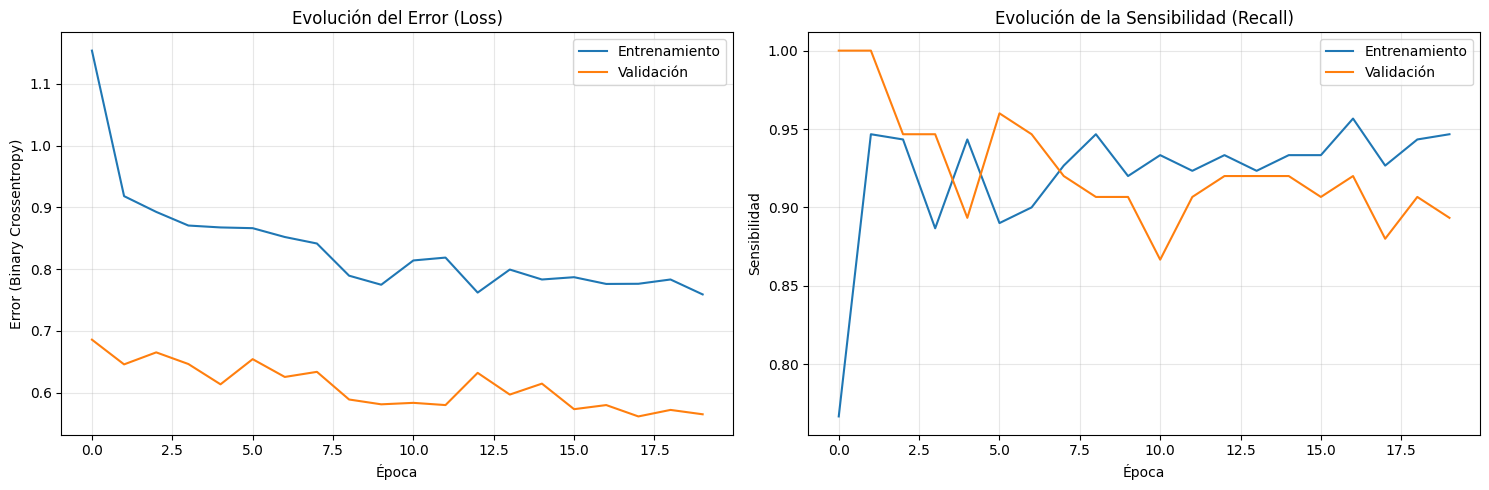

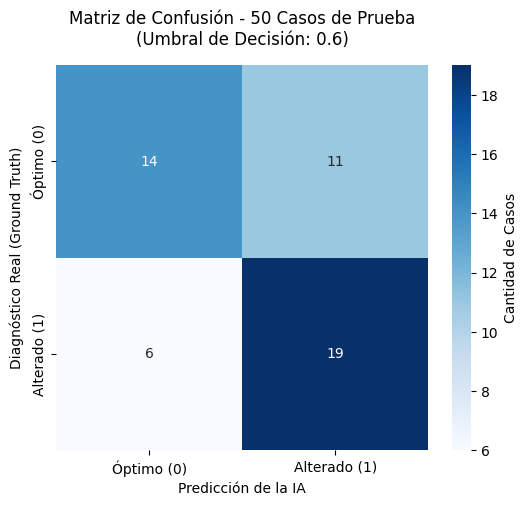


--- REPORTE CLÍNICO (SET DE 50 CASOS AISLADOS) ---
              precision    recall  f1-score   support

      Óptimo       0.70      0.56      0.62        25
    Alterado       0.63      0.76      0.69        25

    accuracy                           0.66        50
   macro avg       0.67      0.66      0.66        50
weighted avg       0.67      0.66      0.66        50



In [9]:
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.metrics import confusion_matrix, classification_report

print("\n6. Generando gráficas...")

# ==========================================
# A. CURVAS DE APRENDIZAJE (LOSS Y SENSIBILIDAD)
# ==========================================
fig, ax = plt.subplots(1, 2, figsize=(15, 5))

# Curva de Error (Loss)
ax[0].plot(historial.history['loss'], label='Entrenamiento', color='#1f77b4')
ax[0].plot(historial.history['val_loss'], label='Validación', color='#ff7f0e')
ax[0].set_title('Evolución del Error (Loss)')
ax[0].set_xlabel('Época')
ax[0].set_ylabel('Error (Binary Crossentropy)')
ax[0].legend()
ax[0].grid(alpha=0.3)

# Curva de Sensibilidad
ax[1].plot(historial.history['sensibilidad'], label='Entrenamiento', color='#1f77b4')
ax[1].plot(historial.history['val_sensibilidad'], label='Validación', color='#ff7f0e')
ax[1].set_title('Evolución de la Sensibilidad (Recall)')
ax[1].set_xlabel('Época')
ax[1].set_ylabel('Sensibilidad')
ax[1].legend()
ax[1].grid(alpha=0.3)

plt.tight_layout()
plt.show()

# ==========================================
# B. MATRIZ DE CONFUSIÓN (SOBRE LOS 50 CASOS DEL EXPERIMENTO)
# ==========================================
# Rescatamos los valores reales y las predicciones que ya calculamos
y_true = df_experimento['target'].values
y_pred = predicciones_clase

cm = confusion_matrix(y_true, y_pred)

plt.figure(figsize=(6, 5))
sns.heatmap(cm, annot=True, fmt='d', cmap='Blues',
            xticklabels=['Óptimo (0)', 'Alterado (1)'],
            yticklabels=['Óptimo (0)', 'Alterado (1)'],
            cbar_kws={'label': 'Cantidad de Casos'})
plt.title(f'Matriz de Confusión - 50 Casos de Prueba\n(Umbral de Decisión: {UMBRAL})', pad=15)
plt.ylabel('Diagnóstico Real (Ground Truth)')
plt.xlabel('Predicción de la IA')
plt.show()

# ==========================================
# C. REPORTE CLÍNICO FINAL
# ==========================================
print("\n--- REPORTE CLÍNICO (SET DE 50 CASOS AISLADOS) ---")
print(classification_report(y_true, y_pred, target_names=['Óptimo', 'Alterado']))